# Working with a GTFS feed

Once you have a GTFS feed — fetched with transitio or downloaded from
anywhere else — transitio can open it for analysis, validate it, report what
it found, repair it and edit it. This page uses the feed of Turku's public
transport, which the [Quickstart](quickstart.ipynb) fetched. Let's fetch it
again; `fetch` delivers the copy in its download cache:

In [1]:
import transitio

rec = transitio.place("Turku").recommend("2026-10-14")
result = transitio.fetch(feeds=rec, osm=False, progress=False)
path = result.feeds[0]
path.name

'c267955299d3f74ba34cfbef1d962f4421a1757af444c8e31ab935bbbb448f30-cropped.zip'

## Open a feed

A GTFS feed is a zip archive of text tables: stops, routes, trips, stop times
and so on. `FeedEditor` opens one and reads every table into a `pandas`
DataFrame. Any GTFS zip works the same, for example
`transitio.FeedEditor("my_feed.zip")` for a feed you downloaded yourself:

In [2]:
editor = transitio.FeedEditor(path)
list(editor.tables)

['stop_times.txt',
 'agency.txt',
 'calendar.txt',
 'calendar_dates.txt',
 'feed_info.txt',
 'routes.txt',
 'stops.txt',
 'translations.txt',
 'trips.txt',
 'shapes.txt']

`editor.tables` maps each file name to its table. Let's look at the routes:

In [3]:
routes = editor.tables["routes.txt"]
routes[["route_id", "agency_id", "route_short_name", "route_long_name", "route_type"]].head()

,route_id,agency_id,route_short_name,route_long_name,route_type
0,1,1,1,Lentoasema-Keskusta-Satama,3
1,2,1,1A,Linja-autoasema-Keskusta-Satama,3
2,3,1,1T,"Lentoasema-Keskusta, Satama-Keskusta",3
3,4,1,2,Kohmo-Keskusta-Nättinummi-Mylly,3
4,5,1,2Y,Kohmo-Keskusta-Länsinummi,3


Notice that every value is text: transitio reads the tables as strings, so
that an id such as `01` never turns into the number 1. Convert a column
yourself when you need numbers, for example with `pd.to_numeric`.

## Analyse a feed

With the tables in `pandas`, the usual DataFrame tools answer questions about
the feed. Let's count the trips of each route and list the busiest ones:

In [4]:
trips = editor.tables["trips.txt"]
trip_counts = trips.groupby("route_id").size().rename("trips")
busiest = routes.set_index("route_id").join(trip_counts).sort_values("trips", ascending=False)
busiest[["route_short_name", "route_long_name", "trips"]].head()

,route_short_name,route_long_name,trips
route_id,,,
16,8,Runosmäki-Keskusta-Harittu,1183
6,3,Varissuo-Keskusta-Perno,1161
4,2,Kohmo-Keskusta-Nättinummi-Mylly,955
1,1,Lentoasema-Keskusta-Satama,895
9,4,"Varissuo, Itäkeskus-Skanssi-Keskusta-Halinen",845


`editor.stops` and `editor.shapes` hold the stops and the route shapes as
`GeoDataFrame`s in WGS84 coordinates, ready for maps and spatial analysis:

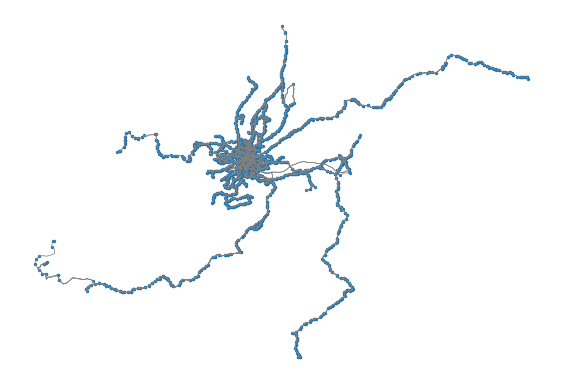

In [5]:
ax = editor.shapes.plot(color="grey", linewidth=0.5, figsize=(7, 7))
editor.stops.plot(ax=ax, color="tab:blue", markersize=2)
ax.set_axis_off()

## Validate a feed

`validate_feed` checks a feed with transitio's Rust core, which emits the
notice codes of the canonical
[gtfs-validator](https://gtfs-validator.mobilitydata.org/). It returns a
dictionary with the notices, the row count of each file and the service
window, among others:

In [6]:
validation = transitio.validate_feed(path)
validation["row_counts"]

{'agency.txt': 4,
 'calendar.txt': 1034,
 'calendar_dates.txt': 66212,
 'feed_info.txt': 1,
 'routes.txt': 99,
 'shapes.txt': 249064,
 'stop_times.txt': 699887,
 'stops.txt': 2954,
 'translations.txt': 1941,
 'trips.txt': 15687}

## Read the validation report

`transitio.report.build_report` turns a validation into a report, merged with
the hosted canonical-validator report when you pass one (`hosted=`):

In [7]:
report = transitio.report.build_report(validation)
for group in report["notices"]:
    print(group["code"], group["severity"], group["source"], group["totalNotices"])

equal_shape_distance_diff_coordinates ERROR local 1751
equal_shape_distance_same_coordinates WARNING local 10000
service_has_no_active_day_of_the_week WARNING local 1034
expired_calendar WARNING local 44
notice_limit_reached WARNING local 1
no_fare_information INFO local 1
unknown_file INFO local 1


Notices follow the canonical
[gtfs-validator](https://gtfs-validator.mobilitydata.org/) codes and
severities, so local and hosted results merge into one document. Each notice
group records whether it was seen locally, by the hosted validator, or both.

`report["summary"]` carries the severity totals (`counts`), the computed
service window (`serviceWindow`, the actual calendar activity, not the
published range), row counts (`rowCounts`) and the provenance block of the
downloaded dataset (`provenance`):

In [8]:
summary = report["summary"]
print(summary["counts"])
print(summary["serviceWindow"])

{'errors': 1751, 'warnings': 11079, 'infos': 2}
['20260810', '20270606']


`transitio.report.render_markdown(report)` and `render_html(report)` write
the report out as a document.

## Repair a feed

`repair_feed` applies the fixes that keep the feed equivalent from the
passenger's point of view, under the [gtfstidy](https://github.com/patrickbr/gtfstidy)
contract, and logs every fix. It stops at 10,000 notices in one file unless
told otherwise, and Turku's shapes.txt has more, so we raise the limit:

In [9]:
repair = transitio.repair_feed(path, "repaired.zip", max_notices_per_file=100_000)
print(len(repair["fixes"]), "fixes;", len(repair["remaining_notices"]), "notices remain")

0 fixes; 15191 notices remain


For Turku's feed the repair finds nothing to fix: none of its notices is one
the repair handles. `repair["fixes"]` lists each fix with its action, its
location and the notice that triggered it, and `remaining_notices` comes from
validating the repaired feed again.

## Edit a feed

`FeedEditor` also edits the feed. Its methods change one entity and
everything that refers to it: `update_stop`, `update_route`, `set_headway`,
`shift_trip`, `drop_route` and `drop_routes`. Let's keep only the routes of
Föli, Turku's own operator (`agency_id` 1), and drop those of the regional
bus companies:

In [10]:
others = routes.loc[routes["agency_id"] != "1", "route_id"]
editor.drop_routes(others)
len(editor.tables["routes.txt"])

87

`drop_routes` removes the routes with their trips, stop times and everything
else that names them, in one step. In Jupyter a progress bar counts the rows
removed; `progress=False` turns it off.

Every edit goes into a change log, one entry per changed row:

In [11]:
print(len(editor.changes), "changes")
change = editor.changes[0]
print(change.action_label, change.kind, change.file)

27416 changes
drop_routes delete routes.txt


`undo()` reverts the newest action and `redo()` applies it again; both
return the action's name. Let's rename a route, take the change back and
apply it again:

In [12]:
editor.update_route("1", route_long_name="Airport - City centre - Harbour")
print(editor.undo(), "->", editor.tables["routes.txt"].loc[0, "route_long_name"])
print(editor.redo(), "->", editor.tables["routes.txt"].loc[0, "route_long_name"])

update_route -> Lentoasema-Keskusta-Satama
update_route -> Airport - City centre - Harbour


`save()` writes the edited feed, validates it and returns the report. By
default it raises `InvalidFeedError` when the validator finds ERROR notices.
Turku's feed already has some in its shapes, so we save with `check=False`,
which keeps the file and still returns the report:

In [13]:
report = editor.save("foli.zip", check=False)
report["row_counts"]["routes.txt"]

87

The change log goes beside the feed, in `foli.changes.txt`.

## Edit a feed in the GUI

```
pip install "transitio-editor[snap]"
transitio edit feed.zip --osm-pbf helsinki.osm.pbf
```

The editor lives in its own package,
[transitio-editor](https://github.com/cafein-py/transitio-editor); the
`transitio edit` command delegates to it.

The editor opens on `http://127.0.0.1:8300`: stops and shapes render on
a map where they can be added, moved and drawn — with the `--osm-pbf`
extract, drawn route shapes snap to the street network, Remix-style.
Saving runs the validator and reports the notice counts. The HTTP API
behind the interface publishes its schema at `/openapi.json`.